In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("Order_Delivery_Performance_Dataset (2).csv")

# Summary Statistics for Shipping Cost
print(df["Shipping_Cost"].describe())

count    10000.000000
mean       275.864800
std        130.602094
min         50.000000
25%        162.000000
50%        277.000000
75%        390.000000
max        500.000000
Name: Shipping_Cost, dtype: float64


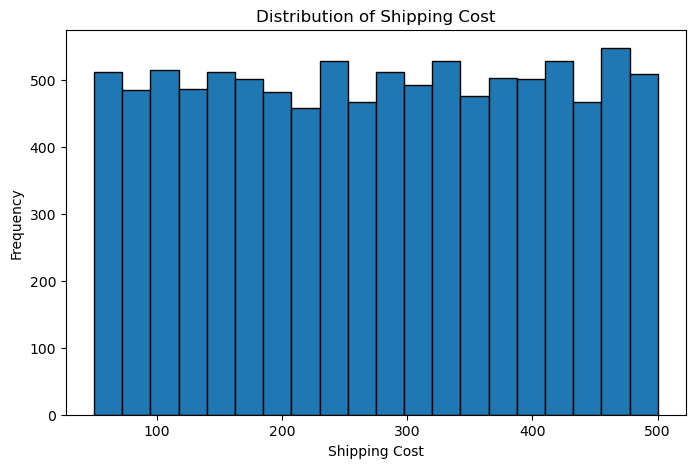

In [2]:
## EDA on Shipping_Cost – Distribution

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["Shipping_Cost"], bins=20, edgecolor="black")
plt.title("Distribution of Shipping Cost")
plt.xlabel("Shipping Cost")
plt.ylabel("Frequency")
plt.show()

In [3]:
## EDA on Order_Value – Summary Statistics

print(df["Order_Value"].describe())

count    10000.000000
mean     25141.207900
std      14363.168026
min        203.000000
25%      12876.500000
50%      25185.500000
75%      37423.000000
max      49995.000000
Name: Order_Value, dtype: float64


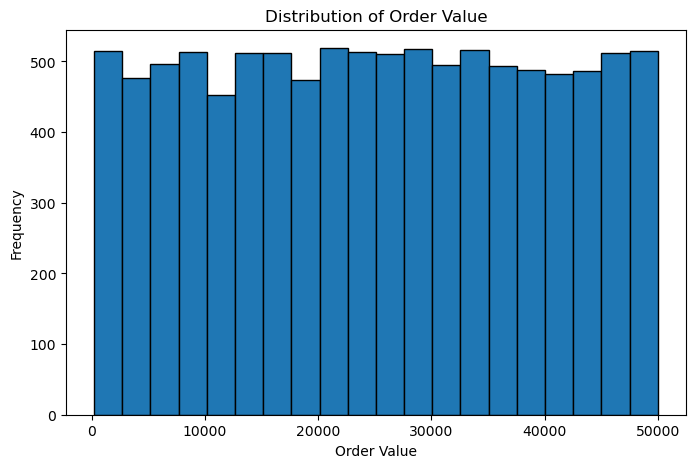

In [4]:
## EDA on Order_Value – Distribution

plt.figure(figsize=(8,5))
plt.hist(df["Order_Value"], bins=20, edgecolor="black")
plt.title("Distribution of Order Value")
plt.xlabel("Order Value")
plt.ylabel("Frequency")
plt.show()

In [5]:
## Segment Analysis by Delivery_Status

delivery_status = df.groupby("Delivery_Status").agg(
    Total_Orders=("Order_ID", "count"),
    Total_Order_Value=("Order_Value", "sum"),
    Average_Order_Value=("Order_Value", "mean"),
    Total_Shipping_Cost=("Shipping_Cost", "sum"),
    Average_Shipping_Cost=("Shipping_Cost", "mean")
)

print(delivery_status)

                 Total_Orders  Total_Order_Value  Average_Order_Value  \
Delivery_Status                                                         
Cancelled                 812           20309437         25011.621921   
Delayed                  1716           43186553         25166.988928   
On Time                  7472          187916089         25149.369513   

                 Total_Shipping_Cost  Average_Shipping_Cost  
Delivery_Status                                              
Cancelled                     215655             265.584975  
Delayed                       478095             278.610140  
On Time                      2064898             276.351445  


In [6]:
## Segment Analysis by Region

region_analysis = df.groupby("Region").agg(
    Total_Orders=("Order_ID", "count"),
    Total_Order_Value=("Order_Value", "sum"),
    Average_Order_Value=("Order_Value", "mean"),
    Total_Shipping_Cost=("Shipping_Cost", "sum"),
    Average_Shipping_Cost=("Shipping_Cost", "mean")
)

print(region_analysis)

         Total_Orders  Total_Order_Value  Average_Order_Value  \
Region                                                          
Central          2032           50922941         25060.502461   
East             2040           51443037         25217.175000   
North            1968           49026875         24912.029980   
South            1959           50401160         25728.004084   
West             2001           49618066         24796.634683   

         Total_Shipping_Cost  Average_Shipping_Cost  
Region                                               
Central               561870             276.510827  
East                  559143             274.089706  
North                 540913             274.854167  
South                 544853             278.128127  
West                  551869             275.796602  


In [7]:
## Segment Analysis by Product_Category

product_category = df.groupby("Product_Category").agg(
    Total_Orders=("Order_ID", "count"),
    Total_Order_Value=("Order_Value", "sum"),
    Average_Order_Value=("Order_Value", "mean"),
    Total_Shipping_Cost=("Shipping_Cost", "sum"),
    Average_Shipping_Cost=("Shipping_Cost", "mean")
)

print(product_category)

                  Total_Orders  Total_Order_Value  Average_Order_Value  \
Product_Category                                                         
Beauty                    1625           39886421         24545.489846   
Electronics               1678           42025440         25044.958284   
Fashion                   1769           45007234         25442.189938   
Grocery                   1657           41932007         25305.978877   
Home                      1657           41232333         24883.725407   
Sports                    1614           41328644         25606.346964   

                  Total_Shipping_Cost  Average_Shipping_Cost  
Product_Category                                              
Beauty                         449787             276.792000  
Electronics                    463549             276.250894  
Fashion                        486447             274.984172  
Grocery                        447636             270.148461  
Home                         

In [8]:
## Derive Date Parts from Order_Date

# Convert Order_Date to datetime
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

# Extract date parts
df["Year"] = df["Order_Date"].dt.year
df["Quarter"] = df["Order_Date"].dt.quarter
df["Month"] = df["Order_Date"].dt.month
df["Month_Name"] = df["Order_Date"].dt.month_name()
df["Week"] = df["Order_Date"].dt.isocalendar().week
df["Day"] = df["Order_Date"].dt.day
df["Day_Name"] = df["Order_Date"].dt.day_name()

print(df[["Order_Date","Year","Quarter","Month","Month_Name","Week","Day","Day_Name"]].head())

  Order_Date  Year  Quarter  Month Month_Name  Week  Day  Day_Name
0 2025-06-15  2025        2      6       June    24   15    Sunday
1 2025-08-03  2025        3      8     August    31    3    Sunday
2 2025-01-26  2025        1      1    January     4   26    Sunday
3 2025-02-22  2025        1      2   February     8   22  Saturday
4 2025-10-27  2025        4     10    October    44   27    Monday


In [9]:
## Derive Features from Processing_Time_Hours

# Convert hours to days
df["Processing_Time_Days"] = df["Processing_Time_Hours"] / 24

# Categorize Processing Time
df["Processing_Category"] = pd.cut(
    df["Processing_Time_Hours"],
    bins=[0, 12, 24, 48, float("inf")],
    labels=["Fast", "Normal", "Slow", "Very Slow"]
)

print(df[["Processing_Time_Hours",
          "Processing_Time_Days",
          "Processing_Category"]].head())

   Processing_Time_Hours  Processing_Time_Days Processing_Category
0                     20              0.833333              Normal
1                      9              0.375000                Fast
2                     29              1.208333                Slow
3                     25              1.041667                Slow
4                     59              2.458333           Very Slow


In [10]:
## Verify Newly Created Columns

print(df.info())

print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Order_ID                10000 non-null  object        
 1   Customer_ID             10000 non-null  object        
 2   Order_Date              10000 non-null  datetime64[ns]
 3   Processing_Time_Hours   10000 non-null  int64         
 4   Shipping_Date           10000 non-null  object        
 5   Expected_Delivery_Date  10000 non-null  object        
 6   Actual_Delivery_Date    10000 non-null  object        
 7   Delivery_Time_Days      10000 non-null  float64       
 8   Delivery_Status         10000 non-null  object        
 9   Delay_Days              10000 non-null  float64       
 10  Cancellation            10000 non-null  object        
 11  Cancellation_Reason     10000 non-null  object        
 12  Courier                 10000 non-null  object 